In [146]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image

# --- 1. Konfiguration ---
dataset_path = '../data/processed/dataset_idle_mel/' # Dein Ordner mit den gesunden Bildern
batch_size = 16

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. Dataset & Loader erstellen ---
# ImageFolder erwartet Unterordner, falls deine Bilder direkt in dataset_idle liegen,
# nutzen wir ein einfaches Custom Dataset oder schieben sie kurz in einen Unterordner 'healthy'
if any(os.path.isdir(os.path.join(dataset_path, d)) for d in os.listdir(dataset_path)):
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=data_transforms)
else:
    # Falls keine Unterordner da sind, nehmen wir eine einfache Liste
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, root, transform):
            self.root = root
            self.transform = transform
            self.files = [f for f in os.listdir(root) if f.endswith(('.png', '.jpg'))]
        def __len__(self): return len(self.files)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.root, self.files[i])).convert('RGB')
            return self.transform(img), 0 # Dummy Label

    full_dataset = SimpleDataset(dataset_path, data_transforms)

train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset geladen: {len(full_dataset)} gesunde Bilder gefunden.")

Dataset geladen: 283 gesunde Bilder gefunden.


In [180]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Die Autoencoder Architektur ---
import torch
import torch.nn as nn

class MotorAutoencoder(nn.Module):
    def __init__(self, bottleneck_size=128):
        super(MotorAutoencoder, self).__init__()
        
        # Encoder: Extrahiert Merkmale aus dem Spektrogramm
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),   # 112x112
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 56x56
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 28x28
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 3, stride=2, padding=1), # 14x14
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )
        
        # Das eigentliche Bottleneck (Flaschenhals)
        self.flatten = nn.Flatten()
        self.fc_bottleneck = nn.Linear(512 * 14 * 14, bottleneck_size)
        self.bottleneck_bn = nn.BatchNorm1d(bottleneck_size) # Stabilisiert den Loss
        self.relu = nn.ReLU() # Erzeugt Nicht-Linearität
        
        # Decoder-Vorbereitung
        self.decoder_fc = nn.Linear(bottleneck_size, 512 * 14 * 14)
        
        # Decoder: Rekonstruiert das Bild aus dem Bottleneck
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1), # 28x28
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # 56x56
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 112x112
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 3, 3, stride=2, padding=1, output_padding=1),   # 224x224
        )

    def forward(self, x):
        # Encoding
        x = self.encoder_conv(x)
        x = self.flatten(x)
        x = self.fc_bottleneck(x)
        x = self.bottleneck_bn(x)
        x = self.relu(x)
        
        # Decoding
        x = self.decoder_fc(x)
        x = x.view(-1, 512, 14, 14)
        x = self.decoder_conv(x)
        return x

# --- 2. Modell & Training vorbereiten ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
autoencoder = MotorAutoencoder().to(device)

# WICHTIG: Wir trainieren NUR auf gesunden Daten (train_dataset)
# Der Loss ist hier der Mean Squared Error (MSE) zwischen Original und Rekonstruktion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# --- 3. Training Loop ---
num_epochs = 50 # Erhöhe auf 50, da wir jetzt einen Scheduler haben
print(f"Starte Training auf {device}...")

for epoch in range(num_epochs):
    autoencoder.train()
    running_loss = 0.0
    
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        
        optimizer.zero_grad()
        outputs = autoencoder(inputs)
        
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    
    # Der Scheduler braucht den Durchschnitts-Loss der Epoche
    scheduler.step(epoch_loss)
    
    # Optional: Aktuelle Learning Rate ausgeben
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoche {epoch+1:02d} | MSE Loss: {epoch_loss:.6f} | LR: {current_lr:.6f}")


Starte Training auf mps...
Epoche 01 | MSE Loss: 1.803550 | LR: 0.000100
Epoche 02 | MSE Loss: 1.104841 | LR: 0.000100
Epoche 03 | MSE Loss: 0.772636 | LR: 0.000100
Epoche 04 | MSE Loss: 0.593110 | LR: 0.000100
Epoche 05 | MSE Loss: 0.481297 | LR: 0.000100
Epoche 06 | MSE Loss: 0.391920 | LR: 0.000100
Epoche 07 | MSE Loss: 0.331653 | LR: 0.000100
Epoche 08 | MSE Loss: 0.289981 | LR: 0.000100
Epoche 09 | MSE Loss: 0.253695 | LR: 0.000100
Epoche 10 | MSE Loss: 0.229487 | LR: 0.000100
Epoche 11 | MSE Loss: 0.200394 | LR: 0.000100
Epoche 12 | MSE Loss: 0.178991 | LR: 0.000100
Epoche 13 | MSE Loss: 0.161154 | LR: 0.000100
Epoche 14 | MSE Loss: 0.151399 | LR: 0.000100
Epoche 15 | MSE Loss: 0.138701 | LR: 0.000100
Epoche 16 | MSE Loss: 0.133362 | LR: 0.000100
Epoche 17 | MSE Loss: 0.122140 | LR: 0.000100
Epoche 18 | MSE Loss: 0.116830 | LR: 0.000100
Epoche 19 | MSE Loss: 0.119533 | LR: 0.000100
Epoche 20 | MSE Loss: 0.103669 | LR: 0.000100
Epoche 21 | MSE Loss: 0.097937 | LR: 0.000100
Epoche 

In [181]:
torch.save(autoencoder.state_dict(), "../models/s1000_CAE_MEL_annomaly.pth")

In [182]:
def check_anomaly(img_path, model, transform):
    model.eval()
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        reconstruction = model(input_tensor)
        loss = criterion(reconstruction, input_tensor)
        score = loss.item()
    
    # --- De-Normalisierung für die Anzeige ---
    # Die Werte, die du in transforms.Normalize verwendet hast:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    def denormalize(img):
        # Zurück von Tensor-Format (C, H, W) zu Numpy (H, W, C)
        img = img.squeeze().cpu().numpy().transpose(1, 2, 0)
        # Umkehrung: x = (y * std) + mean
        img = (img * std) + mean
        return np.clip(img, 0, 1) # Sicherstellen, dass wir im Bereich [0, 1] bleiben

    orig_vis = denormalize(input_tensor)
    recon_vis = denormalize(reconstruction)
    
    # Differenz-Map (hier ist Clipping nicht nötig, da wir Unterschiede zeigen)
    diff = np.abs(orig_vis - recon_vis).mean(axis=2)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(orig_vis); plt.title("Original (Normal)")
    plt.subplot(1, 3, 2); plt.imshow(recon_vis); plt.title("Rekonstruktion")
    plt.subplot(1, 3, 3); plt.imshow(diff, cmap='hot'); plt.title(f"Differenz (Score: {score:.6f})")
    plt.show()
    
    return score

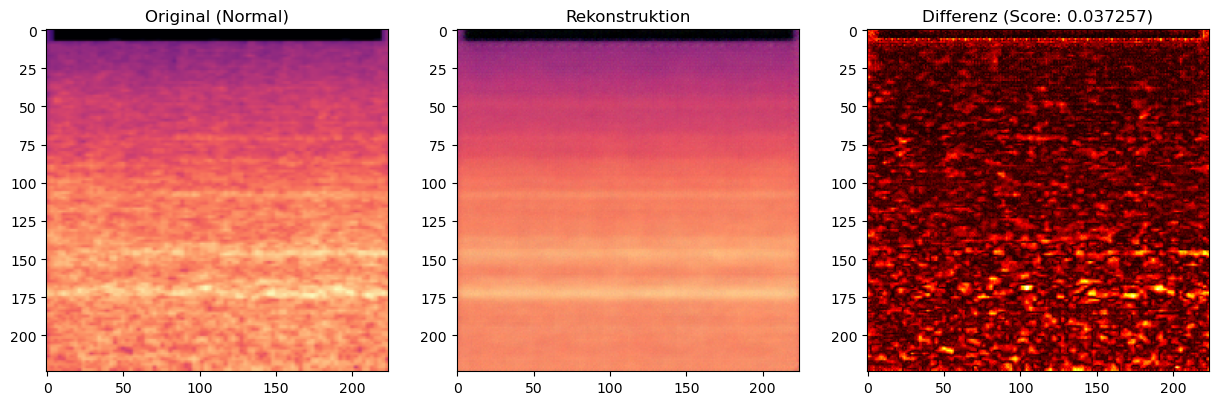

Anomalie-Score für dieses Bild: 0.037257


In [183]:
# Der Aufruf benötigt das Bild, das Modell UND die Vorverarbeitung (data_transforms)
score = check_anomaly(
    '../data/processed/dataset_idle_mel/S1000R_2014_YoutubeVToldsMotoShow_idle_2.00s.png', 
    autoencoder, 
    data_transforms
)

print(f"Anomalie-Score für dieses Bild: {score:.6f}")

In [184]:
import os
import torch
import pandas as pd
import numpy as np

def generate_score_table(healthy_dir, defective_dir, model, transform):
    """
    Erstellt eine Tabelle mit Anomalie-Scores für alle Bilder in den Zielordnern.
    """
    model.eval()
    device = next(model.parameters()).device
    all_results = []
    
    folders = [
        (healthy_dir, "Gesund"),
        (defective_dir, "Defekt")
    ]
    
    print("Berechne Scores für alle Segmente...")
    
    with torch.no_grad():
        for folder_path, label in folders:
            if not os.path.exists(folder_path):
                print(f"Warnung: Pfad nicht gefunden: {folder_path}")
                continue
            
            files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
            for f in files:
                img_path = os.path.join(folder_path, f)
                
                # Bild laden und transformieren
                img_pil = Image.open(img_path).convert('RGB')
                input_tensor = transform(img_pil).unsqueeze(0).to(device)
                
                # Rekonstruktion durch den Autoencoder
                output = model(input_tensor)
                
                # MSE Score berechnen (Anomalie-Maß)
                # Wir berechnen den Fehler zwischen Original-Tensor und Rekonstruktion
                loss = torch.nn.functional.mse_loss(input_tensor, output)
                score = loss.item()
                
                all_results.append({
                    'Klasse': label,
                    'Datei': f,
                    'Anomalie_Score': score
                })

    # In DataFrame umwandeln
    df = pd.DataFrame(all_results)
    
    # Statistiken zur Einordnung berechnen
    avg_healthy = df[df['Klasse'] == "Gesund"]['Anomalie_Score'].mean()
    
    # Abweichung in % vom gesunden Durchschnitt berechnen
    df['Abweichung_zu_Gesund_%'] = ((df['Anomalie_Score'] - avg_healthy) / avg_healthy) * 100
    
    # Tabelle sortieren: Höchste Scores zuerst
    df = df.sort_values(by='Anomalie_Score', ascending=False).reset_index(drop=True)
    
    return df

# --- Durchführung ---
# 1. Tabelle generieren
results_table = generate_score_table(
    '../data/processed/dataset_idle_mel/', 
    '../data/processed/dataset_idle_mel_defective/', 
    autoencoder, 
    data_transforms
)

# 2. Anzeige der Top 20 Ergebnisse
print("\n--- Top 20 Anomalie-Ergebnisse ---")
print(results_table.head(20).to_string())

# 3. Zusammenfassung pro Klasse
print("\n--- Durchschnittswerte pro Klasse ---")
summary = results_table.groupby('Klasse')['Anomalie_Score'].agg(['mean', 'std', 'min', 'max'])
print(summary)

# 4. Optional: Speichern als CSV für Excel/Paper
# results_table.to_csv('s1000_anomaly_results.csv', index=False)

Berechne Scores für alle Segmente...

--- Top 20 Anomalie-Ergebnisse ---
    Klasse                                                             Datei  Anomalie_Score  Abweichung_zu_Gesund_%
0   Defekt    S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_10.75s.png        0.178817              244.223977
1   Defekt    S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_11.00s.png        0.178204              243.043109
2   Defekt     S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_1.50s.png        0.177393              241.482884
3   Defekt     S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_2.75s.png        0.175892              238.593176
4   Defekt     S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_1.25s.png        0.174873              236.631249
5   Defekt    S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_10.25s.png        0.171926              230.959428
6   Defekt     S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_9.50s.png        0.169292              22

In [185]:
def get_domain_relative_results(df):
    """
    Normalisiert die Scores innerhalb jeder Domäne (Garage / YouTube).
    Ein Score von 1.0 bedeutet: Entspricht genau dem gesunden Durchschnitt der Domäne.
    """
    normalized_dfs = []
    
    for domain in df['Domäne'].unique():
        domain_df = df[df['Domäne'] == domain].copy()
        
        # Basiswert: Median der gesunden Proben in dieser Domäne
        healthy_baseline = domain_df[domain_df['Klasse'] == "Gesund"]['Anomalie_Score'].median()
        
        # Relative Abweichung berechnen (Faktor)
        domain_df['Relative_Anomalie'] = domain_df['Anomalie_Score'] / healthy_baseline
        normalized_dfs.append(domain_df)
    
    full_df = pd.concat(normalized_dfs)
    
    # Neuer universeller Threshold: Ein Defekt muss z.B. 25% über der Baseline liegen
    rel_threshold = 1.25 
    full_df['Finale_Diagnose'] = full_df['Relative_Anomalie'].apply(
        lambda x: 'DEFEKT' if x > rel_threshold else 'OK'
    )
    
    return full_df

# --- Anwendung ---
df_final = get_domain_relative_results(final_results)

# Statistische Auswertung der neuen Methode
summary_rel = df_final.groupby(['Domäne', 'Klasse', 'Finale_Diagnose']).size().unstack(fill_value=0)
print("\n--- ERGEBNIS NACH DOMÄNEN-NORMALISIERUNG ---")
print(summary_rel)


--- ERGEBNIS NACH DOMÄNEN-NORMALISIERUNG ---
Finale_Diagnose  DEFEKT   OK
Domäne  Klasse              
Garage  Gesund       21  208
YouTube Defekt       95    3
        Gesund        0   54


In [186]:
from sklearn.metrics import classification_report, confusion_matrix

# Wir erstellen die "True Labels" (0 für Gesund, 1 für Defekt)
y_true = df_final['Klasse'].apply(lambda x: 1 if x == 'Defekt' else 0).values
# Und die "Predicted Labels" (0 für OK, 1 für DEFEKT)
y_pred = df_final['Finale_Diagnose'].apply(lambda x: 1 if x == 'DEFEKT' else 0).values

print("\n--- KLASSIFIZIERUNGSBERICHT ---")
print(classification_report(y_true, y_pred, target_names=['Gesund', 'Defekt']))

# Wenn du wissen willst, welche 39 Garagen-Bilder noch Alarm schlagen:
false_positives = df_final[(df_final['Domäne'] == 'Garage') & (df_final['Finale_Diagnose'] == 'DEFEKT')]
print(f"\nBeispiele für Fehlalarme in der Garage:\n{false_positives['Datei'].head(10)}")


--- KLASSIFIZIERUNGSBERICHT ---
              precision    recall  f1-score   support

      Gesund       0.99      0.93      0.96       283
      Defekt       0.82      0.97      0.89        98

    accuracy                           0.94       381
   macro avg       0.90      0.95      0.92       381
weighted avg       0.95      0.94      0.94       381


Beispiele für Fehlalarme in der Garage:
0     S1000R_2017_AndreRobert_idle_8.75s.png
1    S1000R_2017_AndreRobert_idle_12.75s.png
2    S1000R_2017_AndreRobert_idle_13.00s.png
3    S1000R_2017_AndreRobert_idle_13.75s.png
4    S1000R_2017_AndreRobert_idle_13.50s.png
5    S1000R_2017_AndreRobert_idle_13.25s.png
6    S1000R_2017_AndreRobert_idle_14.00s.png
7    S1000R_2017_AndreRobert_idle_12.50s.png
8    S1000R_2017_AndreRobert_idle_14.25s.png
9    S1000R_2017_AndreRobert_idle_12.25s.png
Name: Datei, dtype: str


In [199]:
import pandas as pd
from sklearn.metrics import classification_report

def evaluate_smoothed_metrics(df, window_size=3, rel_threshold=1.25):
    """
    Berechnet geglättete Scores pro Aufnahme und gibt den Klassifizierungsbericht aus.
    """
    # 1. Wir extrahieren den Basis-Dateinamen (ohne den Zeitstempel am Ende)
    # Beispiel: 'S1000R_2017_AndreRobert_idle_13.25s.png' -> 'S1000R_2017_AndreRobert'
    df['Base_File'] = df['Datei'].apply(lambda x: "_".join(x.split('_')[:-2]))
    
    smoothed_results = []
    
    # 2. Wir gehen jede Aufnahme einzeln durch
    for file in df['Base_File'].unique():
        file_data = df[df['Base_File'] == file].copy()
        
        # Sicherstellen, dass die Segmente zeitlich sortiert sind
        file_data = file_data.sort_values(by='Datei')
        
        # Gleitender Durchschnitt (Moving Average) über die Relative Anomalie
        # min_periods=1 sorgt dafür, dass auch kurze Aufnahmen gewertet werden
        file_data['Smoothed_Score'] = file_data['Relative_Anomalie'].rolling(window=window_size, center=True).max()
        
        smoothed_results.append(file_data)
    
    df_smoothed = pd.concat(smoothed_results)
    
    # 3. Finale Diagnose auf Basis des geglätteten Scores
    df_smoothed['Final_Diag_Smooth'] = df_smoothed['Smoothed_Score'].apply(
        lambda x: 1 if x > rel_threshold else 0
    )
    
    # True Labels (Defekt = 1, Gesund = 0)
    y_true = df_smoothed['Klasse'].apply(lambda x: 1 if x == 'Defekt' else 0).values
    y_pred = df_smoothed['Final_Diag_Smooth'].values
    
    print(f"--- BERICHT MIT ZEITLICHER GLÄTTUNG (Window={window_size}s) ---")
    print(classification_report(y_true, y_pred, target_names=['Gesund', 'Defekt']))
    
    return df_smoothed

# --- Aufruf ---
# Wir nutzen ein 3-Sekunden Fenster, um kurze Ausreißer zu eliminieren
df_final_smoothed = evaluate_smoothed_metrics(df_final, window_size=1, rel_threshold=1.25)

# Check: Wie viele Garagen-Fehler sind noch übrig?
garage_errors = df_final_smoothed[(df_final_smoothed['Domäne'] == 'Garage') & (df_final_smoothed['Final_Diag_Smooth'] == 1)]
print(f"Verbleibende Fehlalarme in der Garage nach Glättung: {len(garage_errors)}")

--- BERICHT MIT ZEITLICHER GLÄTTUNG (Window=1s) ---
              precision    recall  f1-score   support

      Gesund       0.99      0.93      0.96       283
      Defekt       0.82      0.97      0.89        98

    accuracy                           0.94       381
   macro avg       0.90      0.95      0.92       381
weighted avg       0.95      0.94      0.94       381

Verbleibende Fehlalarme in der Garage nach Glättung: 21
